# 02 · Mechanism & Exploration (Exp3) — *how / why / who?*

Behavior decomposition + reward faithfulness + rubric factor structure, then descriptive/exploratory +
persona-matched transcripts. Key figures exported to `results/`. (Outcomes → `01`; preference → `03`.)

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))           # cwd = eda/ -> `import exp3`
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, figures
figures.set_style()
ARMS   = exp3.discover_arms()
SCORES = exp3.load_scores_long(ARMS)
PALETTE = figures.arm_palette(sorted(SCORES.arm.unique()))
METRICS = [m for m in exp3.QUESTIONNAIRE_ORDER if m in SCORES.questionnaire.unique()]
ORACLE_NOISE = 0.10   # oracle reproducibility band (~0.07-0.10 |Δ|, partial-conv EDA): min meaningful diff
print("arms on disk:", [(a.label, len(a.iters)) for a in ARMS])
print("scores_long:", SCORES.shape, "| arms scored:", sorted(SCORES.arm.unique()))
print("exports ->", exp3.RESULTS_DIR)

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 2), ('GRPO_LA0', 4), ('GRPO_LA5', 2)]
scores_long: (12096, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


In [2]:
GENS = training.load_generations(ARMS)
BEH = behavior.behavior_by_iter(ARMS)

## 1 · Behavior, faithfulness & rubric structure

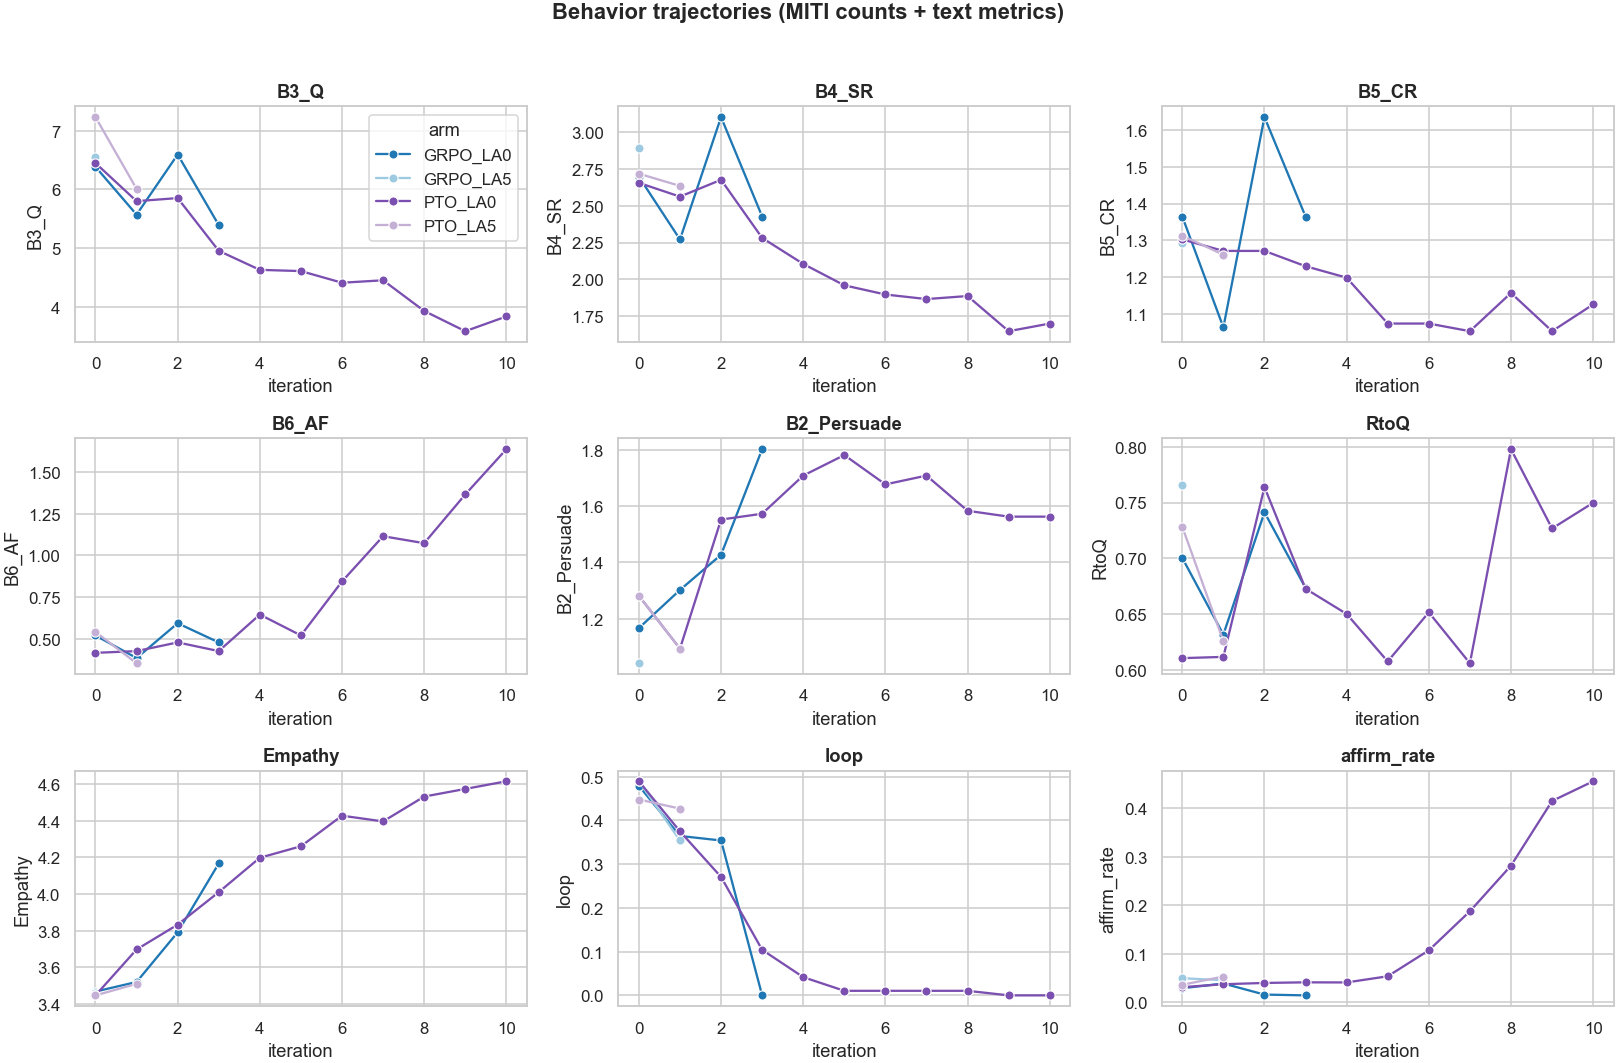

,iteration,B3_Q,B4_SR,B5_CR,B6_AF,B2_Persuade,RtoQ,Empathy,loop,affirm_rate
6,0,6.448,2.656,1.302,0.417,1.281,0.610,3.448,0.490,0.031
7,1,5.802,2.562,1.271,0.427,1.094,0.612,3.698,0.375,0.037
8,2,5.854,2.677,1.271,0.479,1.552,0.764,3.833,0.271,0.040
9,3,4.958,2.281,1.229,0.427,1.573,0.673,4.010,0.104,0.041
10,4,4.635,2.104,1.198,0.646,1.708,0.650,4.198,0.042,0.041
11,5,4.615,1.958,1.073,0.521,1.781,0.607,4.260,0.010,0.054
12,6,4.417,1.896,1.073,0.844,1.677,0.652,4.427,0.010,0.107
13,7,4.458,1.865,1.052,1.115,1.708,0.606,4.396,0.010,0.188
14,8,3.938,1.885,1.156,1.073,1.583,0.798,4.531,0.010,0.282
15,9,3.594,1.646,1.052,1.365,1.562,0.727,4.573,0.000,0.415


'c:\\Users\\baruc\\Desktop\\Projects\\Thesis_PTO_GRPO\\Exp3_PTO_GRPO\\eda\\results\\tables'

In [3]:
BM = [m for m in ["B3_Q","B4_SR","B5_CR","B6_AF","B2_Persuade","RtoQ","Empathy","loop","affirm_rate"] if m in BEH.columns]
bpal = figures.arm_palette(sorted(BEH.arm.unique()))
fig, axes = figures.grid(len(BM), ncols=3)
for ax, m in zip(axes, BM):
    sns.lineplot(BEH, x="iteration", y=m, hue="arm", palette=bpal, marker="o", ax=ax); ax.set_title(m)
    if ax is not axes[0] and ax.get_legend(): ax.legend_.remove()
fig.suptitle("Behavior trajectories (MITI counts + text metrics)", y=1.02, fontweight="bold"); fig.tight_layout()
exp3.save_fig(fig, "behavior_drift", caption="MITI behavior counts (B3_Q questions, B4_SR/B5_CR reflections, B6_AF affirmations, B2_Persuade) + text metrics across iterations."); plt.show()
BT = BEH[BEH.arm=="PTO_LA0"][["iteration"]+BM].round(3); display(BT)
exp3.save_table(BT, "PTO_LA0_behavior_by_iter", caption="PTO_LA0 mean behavior metrics per iteration (MITI counts + text metrics).")

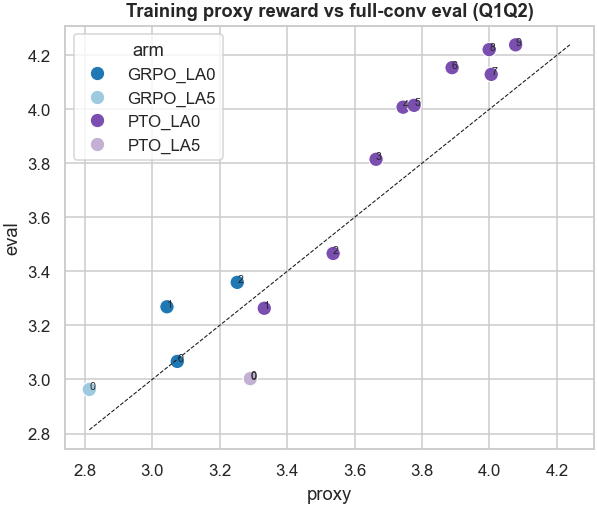

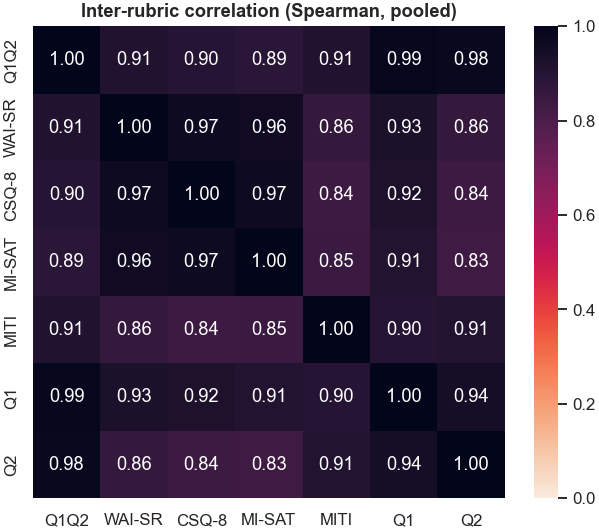

GRPO_LA0: PC1 = 92.9%  loadings={'Q1Q2': 0.445, 'WAI-SR': 0.449, 'CSQ-8': 0.451, 'MI-SAT': 0.454, 'MITI': 0.436}
GRPO_LA5: PC1 = 93.9%  loadings={'Q1Q2': 0.44, 'WAI-SR': 0.449, 'CSQ-8': 0.451, 'MI-SAT': 0.451, 'MITI': 0.445}
PTO_LA0: PC1 = 90.7%  loadings={'Q1Q2': 0.442, 'WAI-SR': 0.454, 'CSQ-8': 0.452, 'MI-SAT': 0.455, 'MITI': 0.432}
PTO_LA5: PC1 = 90.9%  loadings={'Q1Q2': 0.433, 'WAI-SR': 0.455, 'CSQ-8': 0.453, 'MI-SAT': 0.454, 'MITI': 0.441}


In [4]:
proxy = GENS.groupby(["arm","eval_iter"])["score"].mean().rename("proxy").reset_index().rename(columns={"eval_iter":"iteration"})
evalq = SCORES[SCORES.questionnaire=="Q1Q2"].groupby(["arm","iteration"])["score"].mean().rename("eval").reset_index()
faith = proxy.merge(evalq, on=["arm","iteration"])
fig, ax = plt.subplots(figsize=(6.2,5))
sns.scatterplot(faith, x="proxy", y="eval", hue="arm", s=90, palette=figures.arm_palette(sorted(faith.arm.unique())), ax=ax)
for _, r in faith.iterrows(): ax.annotate(int(r.iteration),(r.proxy,r.eval),fontsize=7)
lo,hi=faith[["proxy","eval"]].min().min(),faith[["proxy","eval"]].max().max(); ax.plot([lo,hi],[lo,hi],"k--",lw=.7)
ax.set_title("Training proxy reward vs full-conv eval (Q1Q2)"); plt.show()
corr = stats.rubric_correlation(SCORES)
fig, ax = plt.subplots(figsize=(6,5)); sns.heatmap(corr, annot=True, fmt=".2f", vmin=0, vmax=1, cmap="rocket_r", square=True, ax=ax)
ax.set_title("Inter-rubric correlation (Spearman, pooled)"); fig.tight_layout()
exp3.save_fig(fig, "rubric_correlation", caption="Spearman correlation among the 6 rubric scores (per conversation, pooled)."); plt.show()
for arm in sorted(SCORES.arm.unique()):
    p = stats.rubric_pca(SCORES[SCORES.arm==arm])
    if p["explained_variance_ratio"]: print(f"{arm}: PC1 = {p['explained_variance_ratio'][0]:.1%}  loadings={p['pc1_loadings']}")

## 2 · Descriptive / exploratory

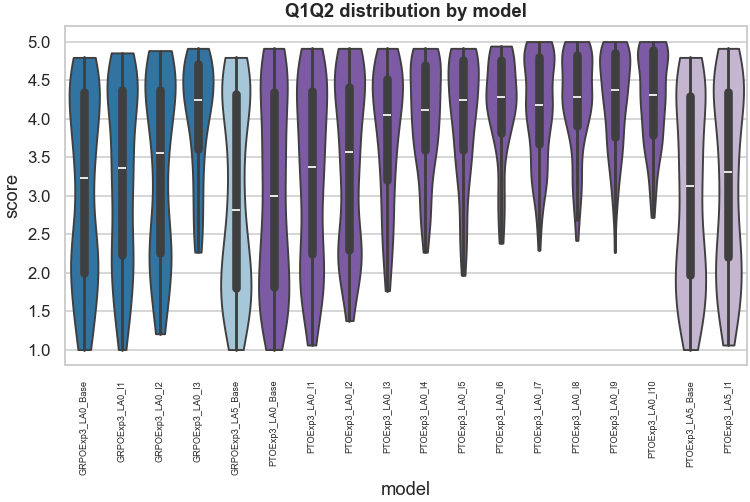

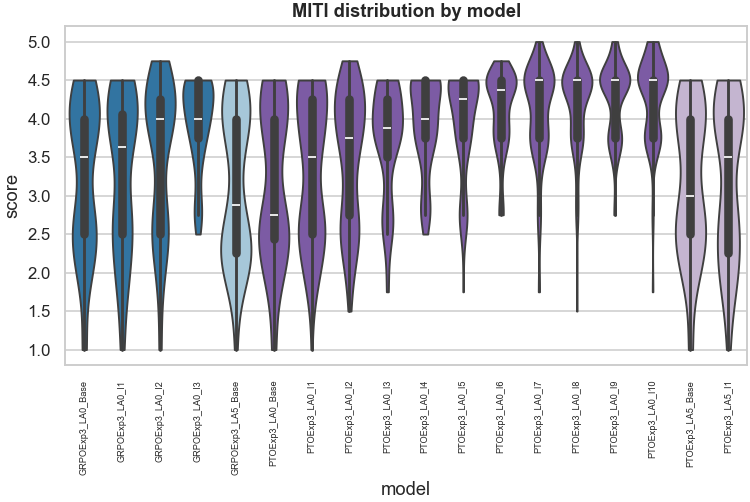

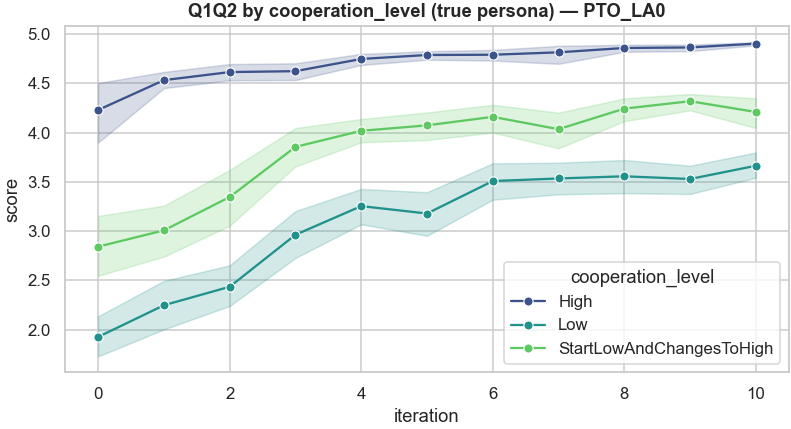

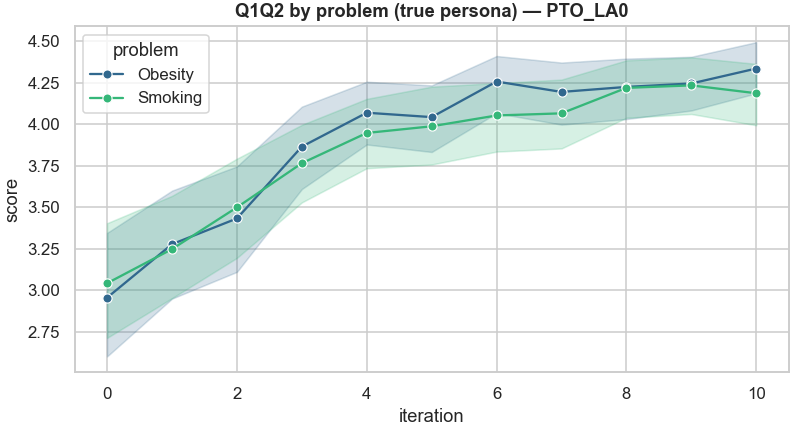

In [5]:
for m in ["Q1Q2","MITI"]:
    d = SCORES[SCORES.questionnaire==m]; order=figures.model_order(SCORES)
    fig, ax = plt.subplots(figsize=(max(8,.4*d.model.nunique()),4))
    sns.violinplot(d, x="model", y="score", order=order, hue="arm", palette=PALETTE, dodge=False, density_norm="width", cut=0, ax=ax)
    ax.set_title(f"{m} distribution by model"); ax.tick_params(axis="x", rotation=90, labelsize=6)
    if ax.get_legend(): ax.legend_.remove()
    plt.show()
for char in ["cooperation_level","problem"]:
    d = SCORES[(SCORES.arm=="PTO_LA0") & (SCORES.questionnaire=="Q1Q2")]
    fig, ax = plt.subplots(figsize=(7.5,4.2))
    sns.lineplot(d, x="iteration", y="score", hue=char, marker="o", palette="viridis", ax=ax)
    ax.set_title(f"Q1Q2 by {char} (true persona) — PTO_LA0"); fig.tight_layout()
    exp3.save_fig(fig, f"heterogeneity_{char}_PTO_LA0", caption=f"PTO_LA0 Q1+Q2 across iterations split by true patient {char}."); plt.show()

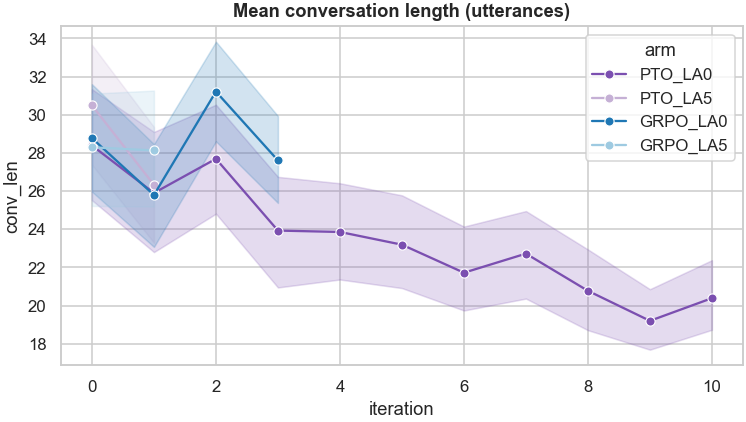

ended_by,nan,patient,therapist
arm,,,
GRPO_LA0,80.0,301.0,3.0
GRPO_LA5,61.0,128.0,3.0
PTO_LA0,178.0,871.0,7.0
PTO_LA5,66.0,124.0,2.0


In [6]:
TEXT = behavior.text_metrics(ARMS, attach_persona=False)
fig, ax = plt.subplots(figsize=(8,4)); sns.lineplot(TEXT, x="iteration", y="conv_len", hue="arm", palette=figures.arm_palette(sorted(TEXT.arm.unique())), marker="o", ax=ax)
ax.set_title("Mean conversation length (utterances)"); plt.show()
rows=[]
for a in ARMS:
    for k in a.iters:
        cdir=a.conv_dir(k)
        for fn in (os.listdir(cdir) if cdir and os.path.isdir(cdir) else []):
            if fn.startswith("conversation_") and fn.endswith(".csv"):
                try: dd=pd.read_csv(os.path.join(cdir,fn))
                except: continue
                rows.append({"arm":a.label,"ended_by":str(dd["session_ended_by"].iloc[0]) if "session_ended_by" in dd else "NA"})
display(pd.DataFrame(rows).groupby(["arm","ended_by"]).size().rename("n").reset_index().pivot_table(index="arm",columns="ended_by",values="n",fill_value=0))

## 3 · Persona-matched transcript evolution

In [7]:
from exp3.personas import persona_order
def file_of_persona(seed,k,pid,n=96): return persona_order(seed,k,n).index(pid)
arm=[a for a in ARMS if a.label=="PTO_LA0"][0]; PERSONA=0
print("persona",PERSONA,"=",exp3.canonical_personas().loc[PERSONA].to_dict(),"\n")
for k in [0,5,10]:
    fi=file_of_persona(arm.seed,k,PERSONA); d=pd.read_csv(os.path.join(arm.conv_dir(k),f"conversation_{fi}.csv"))
    th=d[d.role=="therapist"]["conversation"].astype(str).tolist()
    print(f"==== model_iter_{k} (file conv_{fi}) — {len(th)} therapist turns ====")
    for t in th[1:4]: print("   •"," ".join(t.split())[:240]); print()

persona 0 = {'gender': 'Male', 'age_value': 27, 'problem': 'Smoking', 'problem_time': 'FewMonths', 'tried_to_solve': 'Never', 'cooperation_level': 'Low'} 

==== model_iter_0 (file conv_14) — 10 therapist turns ====
   • I can understand that. Let's talk about your goals. What's the point of this session?

   • OK, so why don't we start by talking about what it is you enjoy about smoking?

   • I can see that. So what do you enjoy about it? Are there any specific activities you like to do?

==== model_iter_5 (file conv_54) — 8 therapist turns ====
   • Oh, right, well that’s ok. Let’s talk about what motivates you to want to stop smoking. What do you see as the biggest barrier to doing so?

   • That’s fair. So, how do you want to approach this conversation? What would you like to achieve from our time together?

   • Oh, I totally understand. I can relate to that. I’m here to help you understand why quitting smoking is important and how you can do it. We can start by exploring the diff

## 4 · Takeaways
- _(behavior drift; proxy-vs-eval gap; PC1 share; who benefits)_